In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
df1 = pd.read_csv('../data/CRMLSSold202505.csv')
df2 = pd.read_csv('../data/CRMLSSold202506.csv')
df3 = pd.read_csv('../data/CRMLSSold202507.csv')
df4 = pd.read_csv('../data/CRMLSSold202508.csv')
df5 = pd.read_csv('../data/CRMLSSold202509.csv')
df6 = pd.read_csv('../data/CRMLSSold202510.csv')
df7 = pd.read_csv('../data/CRMLSSold202511.csv')
df8 = pd.read_csv('../data/CRMLSSold202512.csv')
df9 = pd.read_csv('../data/CRMLSSold202601.csv')
df10 = pd.read_csv('../data/CRMLSSold202602.csv')
df11 = pd.read_csv('../data/CRMLSSold202603.csv')
df12 = pd.read_csv('../data/CRMLSSold202604.csv')
df13 = pd.read_csv('../data/CRMLSSold202605.csv')

df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13], axis=0, ignore_index=True)
df = df.drop(['ListPrice', 'OriginalListPrice'], axis=1)

# Restricting analysis according to Project Document
df = df[df['PropertyType'] == 'Residential']
df = df[df['PropertySubType'] == 'SingleFamilyResidence']

/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_5982/2718417998.py:2: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../data/CRMLSSold202506.csv')
/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_5982/2718417998.py:9: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df9 = pd.read_csv('../data/CRMLSSold202601.csv')


In [3]:
df['ClosePrice'].hasnans

False

(This dataset contains all properties that have a ClosePrice. Their statuses are closed.)

### Listing & Transaction Information:
1. ListingKey
2. ListingKeyNumeric
3. ListingId
4. ListingContractDate
5. PurchaseContractDate
6. ContractStatusChangeDate
7. CloseDate
8. DaysOnMarket
9. MlsStatus

We want to decide which of these features will be most helpful in predicting ClosePrice in our model.

### 1. ListingKey
ListingKey is the primary key.

### 2. ListingKeyNumeric
ListingKeyNumeric seems to be the same as the primary key.

### 3. ListingId
ListingId is also a type of key, with human-identifiable values.

### 4. ListingContractDate
ListingContractDate is the date of the agreement/contract between the seller and the seller's broker. This is stage 1 of the transaction lifecycle.

In [4]:
df_ListingContractDate = df.copy()
df_ListingContractDate['ListingContractDate'] = pd.to_datetime(df_ListingContractDate['ListingContractDate'])
# Convert datetime to a numeric float
df_ListingContractDate['ListingContractDateNumeric'] = df_ListingContractDate['ListingContractDate'].astype('int64') // 10**9 

# correlation coefficient
df_ListingContractDate['ListingContractDateNumeric'].corr(np.log1p(df_ListingContractDate['ClosePrice']))

np.float64(0.047968591387088845)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


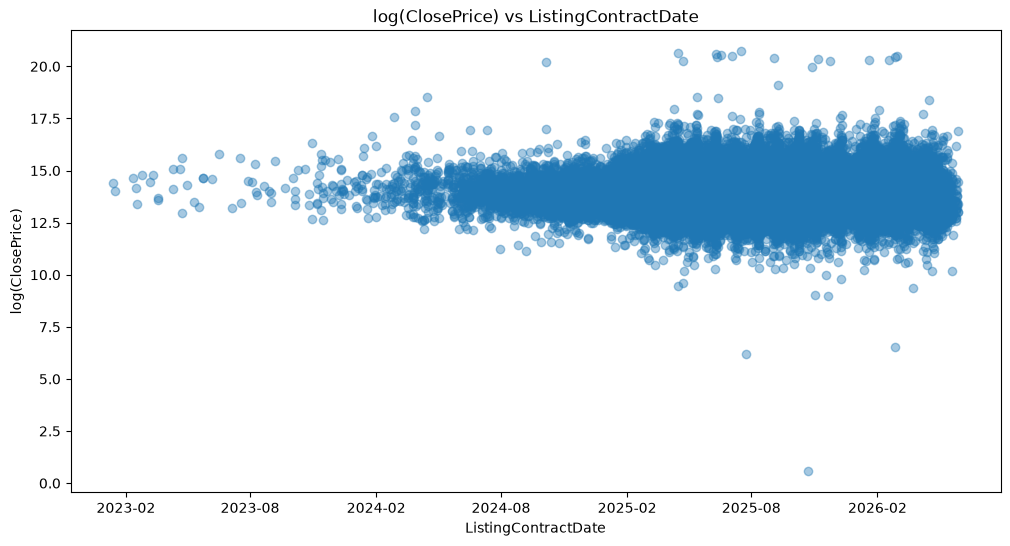

In [5]:
# ignore sparse data before 2023
df_ListingContractDate = df_ListingContractDate[df_ListingContractDate['ListingContractDate'] > pd.to_datetime('2023-01-01')]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_ListingContractDate['ListingContractDate'].sort_values(), np.log(df_ListingContractDate['ClosePrice']), alpha=0.4)

plt.xlabel('ListingContractDate')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs ListingContractDate')

# show a tick every 6 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

When we apply log to ClosePrice, the data seems fairly evenly spread and consistent over time around a y-value of 12.5-16. The correlation coefficient is 0.048, which is statistically significant. This feature may help for our model.

In [6]:
df_ListingContractDate['ListingMonth'] = df_ListingContractDate['ListingContractDate'].dt.to_period('M')
df_ListingContractDate['LogClosePrice'] = np.log(df_ListingContractDate['ClosePrice'])
monthly_stats = df_ListingContractDate.groupby('ListingMonth')['LogClosePrice'].agg(['std', 'count'])
# print(monthly_stats)
# the std converges as the count grows, so the spread of ClosePrice in the above plot increases just because there
# is more data for later dates

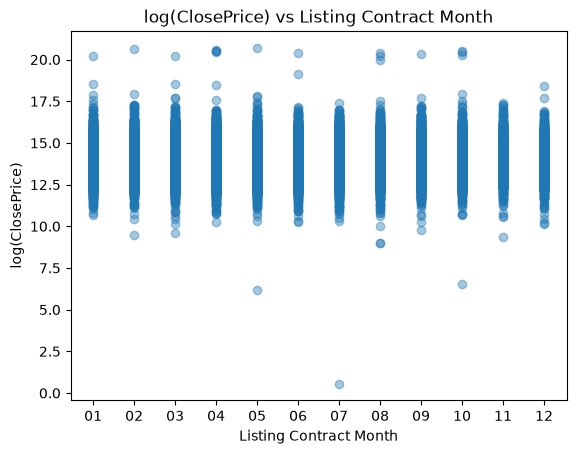

In [7]:
plt.xlabel('Listing Contract Month')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs Listing Contract Month')

# df sorted by month
df_monthly = df.copy()
df_monthly['ListingContractMonth'] = df_monthly['ListingContractDate'].str[5:7]
df_monthly['LogClosePrice'] = np.log(df_monthly['ClosePrice'])
plt.scatter(df_monthly['ListingContractMonth'].sort_values(), np.log(df['ClosePrice']), alpha=0.4);

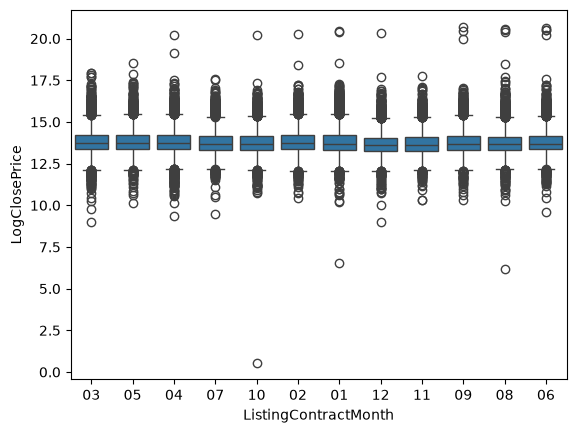

In [8]:
sns.boxplot(df_monthly, x='ListingContractMonth', y='LogClosePrice');

Grouping by month does not look very helpful either, as there do not seem to be significant seasonal trends.

### 5. PurchaseContractDate
This is the date an offer was accepted by contract and the listing was taken off the market.

In [9]:
# PurchaseContractDate has NaN values --> replace with empty string
df_PurchaseContractDate = df.copy()
df_PurchaseContractDate['PurchaseContractDate'] = df['PurchaseContractDate'].fillna("")

In [10]:
df_PurchaseContractDate['PurchaseContractDate'] = pd.to_datetime(df_PurchaseContractDate['PurchaseContractDate'])
# Convert datetime to a numeric float
df_PurchaseContractDate['PurchaseContractDateNumeric'] = df_PurchaseContractDate['PurchaseContractDate'].astype('int64') // 10**9 

df_PurchaseContractDate['PurchaseContractDateNumeric'].corr(np.log1p(df_PurchaseContractDate['ClosePrice']))

np.float64(0.0034072770742251406)

The correlation coefficient between PurchaseContractDate and ClosePrice is very close to 0, so this feature may not be helpful.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


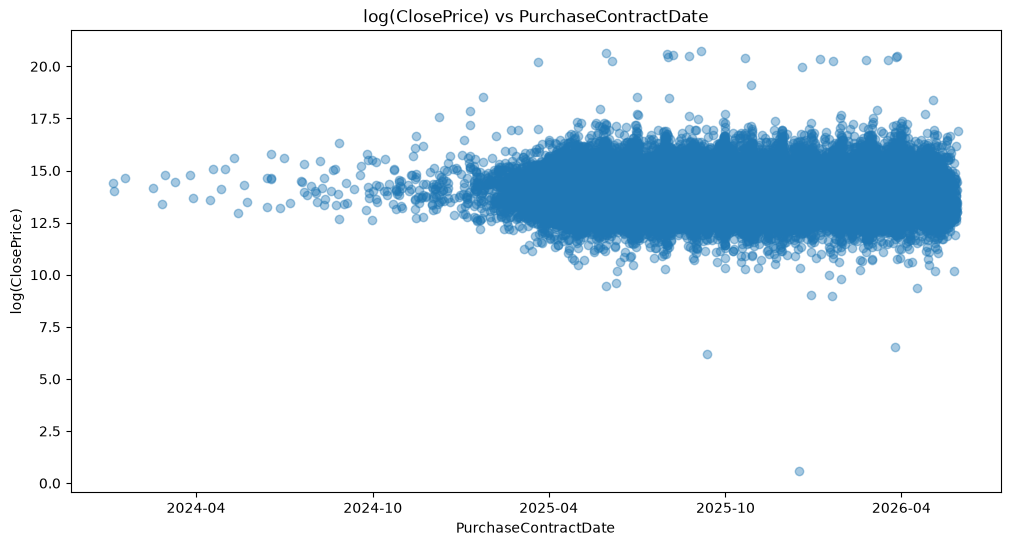

In [11]:
# ignore sparse data before 2024
df_PurchaseContractDate = df_PurchaseContractDate[df_PurchaseContractDate['PurchaseContractDate'] > pd.to_datetime('2024-01-01')]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_PurchaseContractDate['PurchaseContractDate'].sort_values(), np.log(df_PurchaseContractDate['ClosePrice']), alpha=0.4);

plt.xlabel('PurchaseContractDate')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs PurchaseContractDate')

# show a tick every 6 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

The visualization supports this.

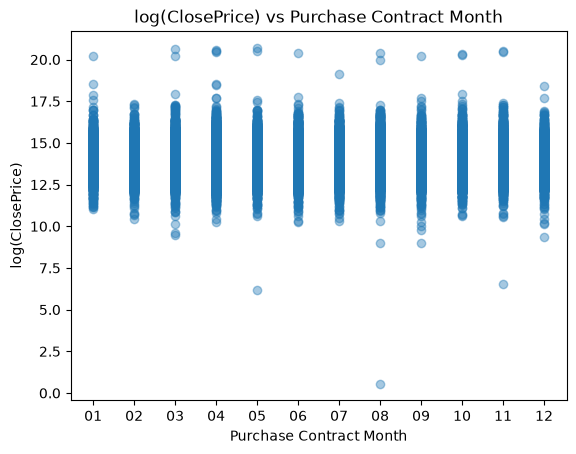

In [12]:
plt.xlabel('Purchase Contract Month')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs Purchase Contract Month')

# df sorted by month
df_PurchaseContractDate['PurchaseContractMonth'] = df['PurchaseContractDate'].str[5:7]
df_PurchaseContractDate['LogClosePrice'] = np.log(df_PurchaseContractDate['ClosePrice'])
plt.scatter(df_PurchaseContractDate['PurchaseContractMonth'].sort_values(), np.log(df_PurchaseContractDate['ClosePrice']), alpha=0.4);

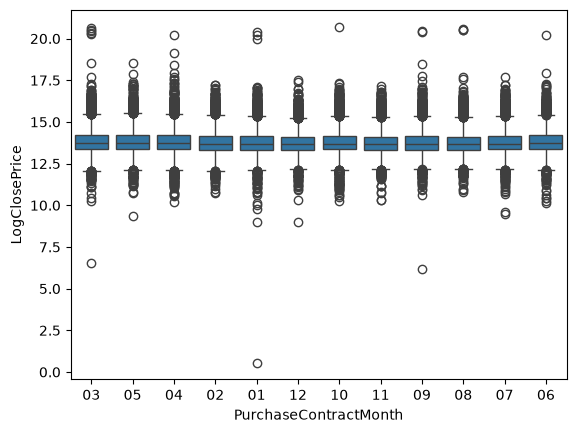

In [13]:
sns.boxplot(df_PurchaseContractDate, x='PurchaseContractMonth', y='LogClosePrice');

There do not seem to be significant seasonal trends here.

### 6. ContractStatusChangeDate
This is the date that there was a change to the contract status.

In [14]:
df_ContractStatusChangeDate = df.copy()
df_ContractStatusChangeDate['ContractStatusChangeDate'] = pd.to_datetime(df_ContractStatusChangeDate['ContractStatusChangeDate'])
# Convert datetime to a numeric float
df_ContractStatusChangeDate['ContractStatusChangeDateNumeric'] = df_ContractStatusChangeDate['ContractStatusChangeDate'].astype('int64') // 10**9 

df_ContractStatusChangeDate['ContractStatusChangeDateNumeric'].corr(np.log1p(df_ContractStatusChangeDate['ClosePrice']))

np.float64(0.0015827339402365041)

No significant relationship here.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


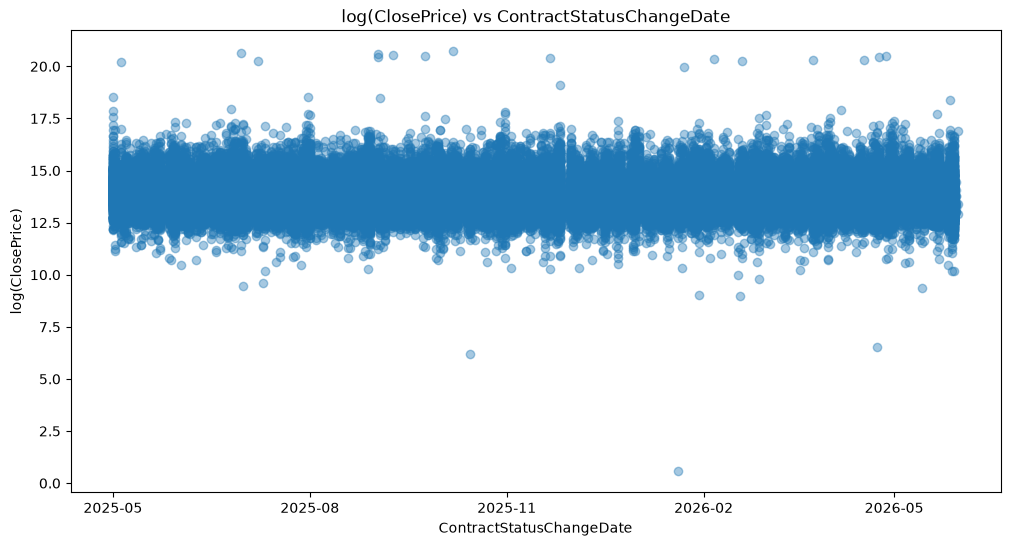

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_ContractStatusChangeDate['ContractStatusChangeDate'].sort_values(), np.log(df_ContractStatusChangeDate['ClosePrice']), alpha=0.4)

plt.xlabel('ContractStatusChangeDate')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs ContractStatusChangeDate')

# show a tick every 3 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3));

The data is highly consistent, but no trends.

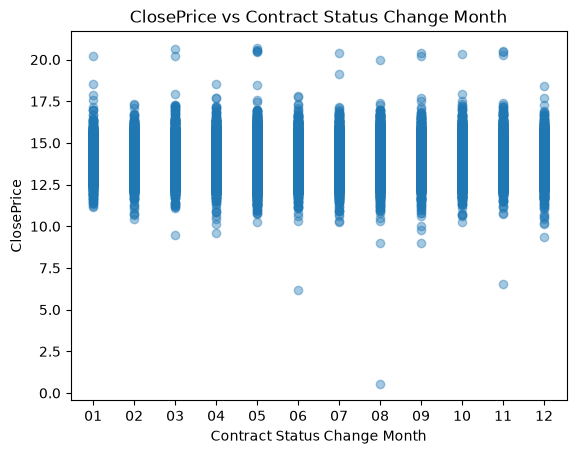

In [16]:
plt.xlabel('Contract Status Change Month')
plt.ylabel('ClosePrice')
plt.title('ClosePrice vs Contract Status Change Month')

# df sorted by month
df_ContractStatusChangeDate['ContractStatusChangeMonth'] = df['ContractStatusChangeDate'].str[5:7]
df_ContractStatusChangeDate['LogClosePrice'] = np.log(df_ContractStatusChangeDate['ClosePrice'])
plt.scatter(df_ContractStatusChangeDate['ContractStatusChangeMonth'].sort_values(), np.log(df_ContractStatusChangeDate['ClosePrice']), alpha=0.4);

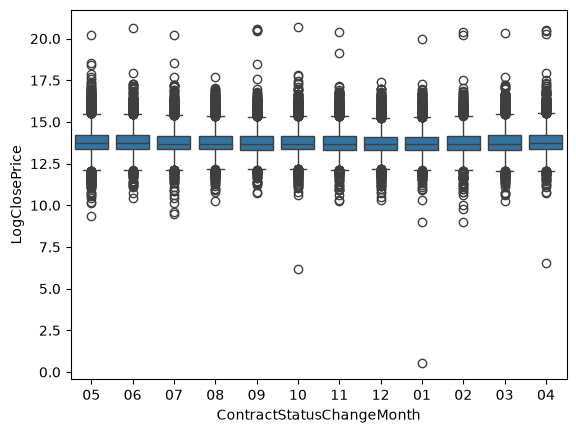

In [17]:
sns.boxplot(df_ContractStatusChangeDate, x='ContractStatusChangeMonth', y='LogClosePrice');

No significant relationship here either.

### 7. CloseDate
The date the purchase agreement/requirement was fulfilled.

In [18]:
df_CloseDate = df.copy()
df_CloseDate['CloseDate'] = pd.to_datetime(df_CloseDate['CloseDate'])
# Convert datetime to a numeric float
df_CloseDate['CloseDateNumeric'] = df_CloseDate['CloseDate'].astype('int64') // 10**9 

df_CloseDate['CloseDateNumeric'].corr(np.log1p(df_CloseDate['ClosePrice']))

np.float64(0.0015815293362251377)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


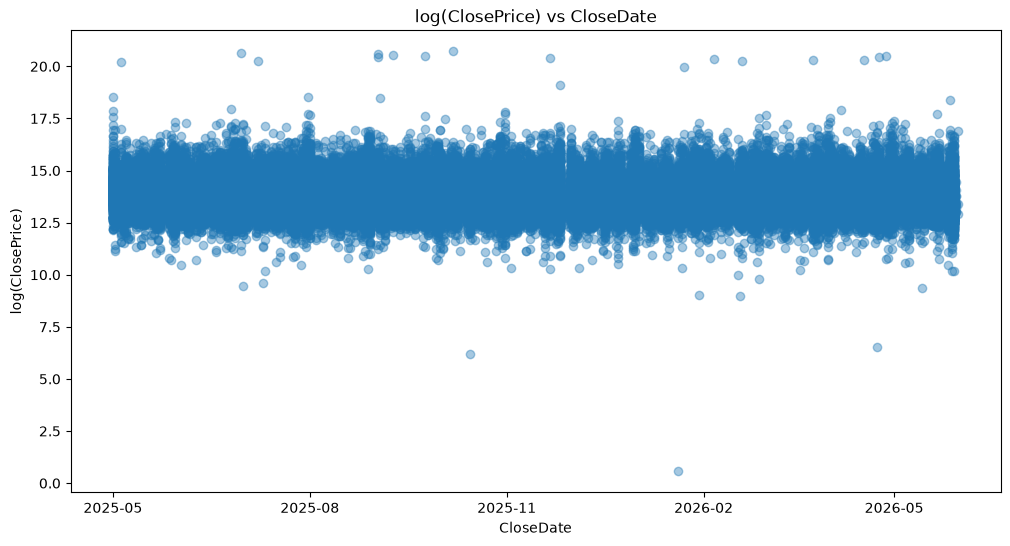

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_CloseDate['CloseDate'].sort_values(), np.log(df_CloseDate['ClosePrice']), alpha=0.4);

plt.xlabel('CloseDate')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs CloseDate')

# show a tick every 3 months on the x axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

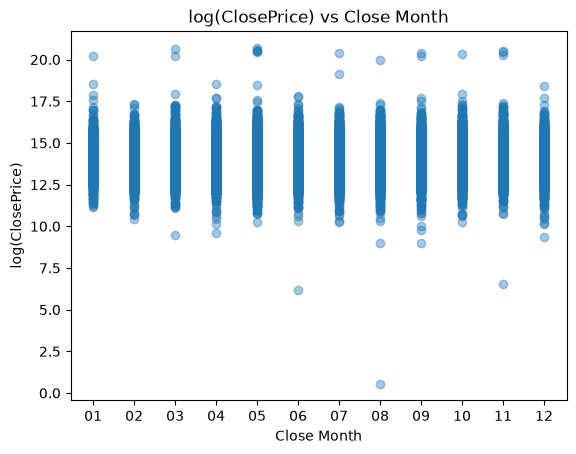

In [20]:
plt.xlabel('Close Month')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs Close Month')

# df sorted by month
df_CloseDate['CloseMonth'] = df['CloseDate'].str[5:7]
df_CloseDate['LogClosePrice'] = np.log(df_CloseDate['ClosePrice'])
plt.scatter(df_CloseDate['CloseMonth'].sort_values(), np.log(df_CloseDate['ClosePrice']), alpha=0.4);

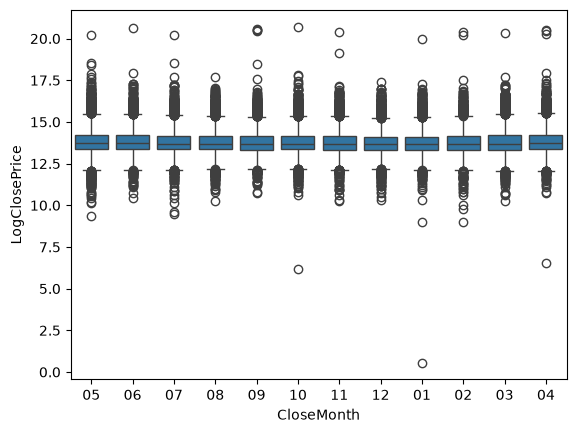

In [21]:
sns.boxplot(df_CloseDate, x='CloseMonth', y='LogClosePrice');

No significant trend.

### 8. DaysOnMarket
The number of days that the listing was on market.
Note: This feature could introduce data leakage, since we don't know how many days on market a property will have before it sells.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


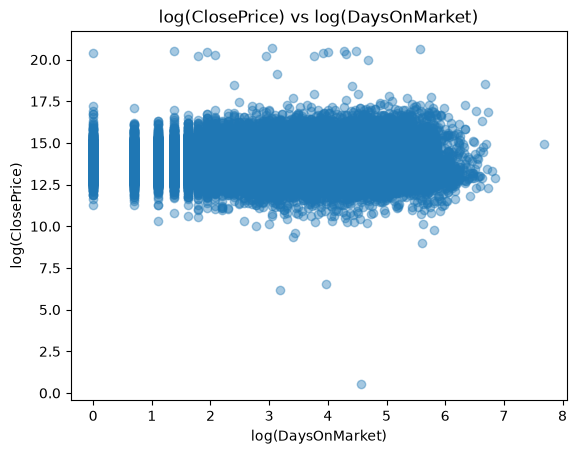

In [22]:
plt.xlabel('log(DaysOnMarket)')
plt.ylabel('log(ClosePrice)')
plt.title('log(ClosePrice) vs log(DaysOnMarket)')

plt.scatter(np.log(df['DaysOnMarket']), np.log(df['ClosePrice']), alpha=0.4);

In [23]:
np.log1p(df['DaysOnMarket']).corr(np.log1p(df['ClosePrice']))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


np.float64(-0.09030179493818988)

This could indicate some correlation.

### 9. MlsStatus
MlsStatus is 'Closed' for all data entries.

### Evaluating these features with Random Forest

In [29]:
from sklearn.ensemble import RandomForestRegressor

# Convert date to numeric features
df['ListingContractDate'] = pd.to_datetime(df['ListingContractDate']).astype('int64') // 10**9 
df['PurchaseContractDate'] = pd.to_datetime(df['PurchaseContractDate']).astype('int64') // 10**9 
df['ContractStatusChangeDate'] = pd.to_datetime(df['ContractStatusChangeDate']).astype('int64') // 10**9 
df['CloseDate'] = pd.to_datetime(df['CloseDate']).astype('int64') // 10**9 

features = [
    'ListingContractDate',
    'PurchaseContractDate',
    'ContractStatusChangeDate',
    'CloseDate',
    'DaysOnMarket'
]
X = df[features].dropna()
y = df['ClosePrice']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importance)

DaysOnMarket                0.999765
PurchaseContractDate        0.000235
ListingContractDate         0.000000
ContractStatusChangeDate    0.000000
CloseDate                   0.000000
dtype: float64


Based on these results, the dates may not be helpful for our model, when DaysOnMarket is the overwhelming feature in this Random Forest model. However, including DaysOnMarket may result in data leakage.

# Results:
ListingContractDate and DaysOnMarket may be helpful for a linear regression model. However, we might not know DaysOnMarket beforehand.